In [1]:
# Cell 1 — Mount Google Drive and extract dataset
from google.colab import drive
drive.mount('/content/drive')

!tar -xf /content/drive/MyDrive/DNN_Dataset/vit_crops_224.tar -C /content

Mounted at /content/drive


In [2]:
# Cell 2 — Verify dataset structure
from pathlib import Path
from collections import Counter

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

CROP_ROOT = Path("/content/vit_crops_224")
TRAIN_DIR = CROP_ROOT / "train"
VAL_DIR   = CROP_ROOT / "val"
TEST_DIR  = CROP_ROOT / "test"
def count_images(split_dir):
    print(f"\n{split_dir.name}:")
    total = 0
    for cls in sorted(d for d in split_dir.iterdir() if d.is_dir()):
        n = sum(1 for f in cls.iterdir() if f.suffix.lower() in IMAGE_EXTS)
        total += n
        print(f"  {cls.name}: {n}")
    print(f"  TOTAL: {total}")

for d in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    count_images(d)


train:
  boat: 12871
  buoy: 4239
  jetski: 2179
  life_saving_appliances: 773
  swimmer: 36937
  TOTAL: 56999

val:
  boat: 2214
  buoy: 560
  jetski: 320
  life_saving_appliances: 330
  swimmer: 6206
  TOTAL: 9630

test:
  boat: 150
  buoy: 150
  jetski: 150
  life_saving_appliances: 150
  swimmer: 150
  TOTAL: 750


In [3]:
#  Imports, seeds, and global config
!pip install -q timm

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from pathlib import Path
from PIL import Image
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
import timm
import shutil

#  Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#  Dataset constants
IMG_SIZE    = 224
NUM_CLASSES = 5
BATCH_SIZE  = 32
EPOCHS      = 5

CLASSES = ["swimmer", "boat", "jetski", "life_saving_appliances", "buoy"]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for i, c in enumerate(CLASSES)}

# Paths
CROP_ROOT  = Path("/content/vit_crops_224")
TRAIN_DIR  = CROP_ROOT / "train"
VAL_DIR    = CROP_ROOT / "val"
TEST_DIR   = CROP_ROOT / "test"

SAVE_DIR        = Path("/content/mobilevit_checkpoints")
BEST_MODEL_PATH = SAVE_DIR / "best_mobilevit_s.pth"
LAST_MODEL_PATH = SAVE_DIR / "last_mobilevit_s.pth"
HISTORY_PATH    = SAVE_DIR / "training_history.csv"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("\nAll imports and config ready.")

Device: cuda
GPU: Tesla T4

All imports and config ready.


In [7]:
# Cell 4 — Dataset class and data loaders

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

class SeaDronesDataset(Dataset):
    """Image dataset with a fixed class-to-index mapping."""

    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir     = Path(root_dir)
        self.class_to_idx = class_to_idx
        self.transform    = transform
        self.samples      = []

        for class_name, class_idx in class_to_idx.items():
            class_folder = self.root_dir / class_name
            if not class_folder.exists():
                print(f"Warning: missing folder {class_folder}")
                continue
            for path in class_folder.iterdir():
                if path.suffix.lower() in IMAGE_EXTS:
                    self.samples.append((path, class_idx))

        print(f"Loaded {len(self.samples):,} images from {self.root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# Transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Datasets
train_dataset = SeaDronesDataset(TRAIN_DIR, class_to_idx, train_transform)
val_dataset   = SeaDronesDataset(VAL_DIR,   class_to_idx, eval_transform)
test_dataset  = SeaDronesDataset(TEST_DIR,  class_to_idx, eval_transform)

# Weighted sampler for class imbalance
train_labels    = [label for _, label in train_dataset.samples]
class_counts    = Counter(train_labels)
total_train     = len(train_labels)

print("\nTrain class distribution:")
for idx, name in idx_to_class.items():
    print(f"  {name}: {class_counts[idx]}")

class_weights   = torch.tensor(
    [total_train / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
)
sample_weights  = [class_weights[l].item() for l in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

#  Data loaders
_kwargs = dict(batch_size=BATCH_SIZE, num_workers=2,
               pin_memory=torch.cuda.is_available())

train_loader = DataLoader(train_dataset, sampler=sampler, **_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **_kwargs)

# Quick batch sanity check
imgs, lbls = next(iter(train_loader))
print(f"\nBatch shape: images={tuple(imgs.shape)}, labels={tuple(lbls.shape)}")
print("Sample labels:", lbls.tolist())

Loaded 56,999 images from /content/vit_crops_224/train
Loaded 9,630 images from /content/vit_crops_224/val
Loaded 750 images from /content/vit_crops_224/test

Train class distribution:
  swimmer: 36937
  boat: 12871
  jetski: 2179
  life_saving_appliances: 773
  buoy: 4239

Batch shape: images=(32, 3, 224, 224), labels=(32,)
Sample labels: [3, 3, 1, 0, 4, 0, 4, 3, 4, 1, 1, 3, 4, 1, 2, 3, 3, 3, 4, 2, 4, 3, 1, 1, 1, 0, 2, 0, 3, 4, 4, 0]


In [8]:
#  Build MobileViT-S with partial fine-tuning

model = timm.create_model("mobilevit_s", pretrained=True, num_classes=NUM_CLASSES)

# Freeze everything, then unfreeze the last stage + head
for param in model.parameters():
    param.requires_grad = False

UNFREEZE_PREFIXES = ("stages.4.", "final_conv.", "head.")
for name, param in model.named_parameters():
    if name.startswith(UNFREEZE_PREFIXES):
        param.requires_grad = True

model = model.to(device)

total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen     = total - trainable

print(f"Total:      {total:,}")
print(f"Trainable:  {trainable:,}  ({100 * trainable / total:.2f}%)")
print(f"Frozen:     {frozen:,}")

print("\nTrainable layers:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {tuple(param.shape)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Total:      4,940,837
Trainable:  2,421,077  (49.00%)
Frozen:     2,519,760

Trainable layers:
  stages.4.0.conv1_1x1.conv.weight: (512, 128, 1, 1)
  stages.4.0.conv1_1x1.bn.weight: (512,)
  stages.4.0.conv1_1x1.bn.bias: (512,)
  stages.4.0.conv2_kxk.conv.weight: (512, 1, 3, 3)
  stages.4.0.conv2_kxk.bn.weight: (512,)
  stages.4.0.conv2_kxk.bn.bias: (512,)
  stages.4.0.conv3_1x1.conv.weight: (160, 512, 1, 1)
  stages.4.0.conv3_1x1.bn.weight: (160,)
  stages.4.0.conv3_1x1.bn.bias: (160,)
  stages.4.1.conv_kxk.conv.weight: (160, 160, 3, 3)
  stages.4.1.conv_kxk.bn.weight: (160,)
  stages.4.1.conv_kxk.bn.bias: (160,)
  stages.4.1.conv_1x1.weight: (240, 160, 1, 1)
  stages.4.1.transformer.0.norm1.weight: (240,)
  stages.4.1.transformer.0.norm1.bias: (240,)
  stages.4.1.transformer.0.attn.qkv.weight: (720, 240)
  stages.4.1.transformer.0.attn.qkv.bias: (720,)
  stages.4.1.transformer.0.attn.proj.weight: (240, 240)
  stages.4.1.transformer.0.attn.proj.bias: (240,)
  stages.4.1.transformer.0.

In [9]:
# Loss, optimizer, and scheduler

# Custom class weights (manually tuned; sqrt-softened vs raw frequency weights
# since WeightedRandomSampler already handles the bulk of imbalance)
CUSTOM_WEIGHTS = torch.tensor(
    [1.50, 1.00, 2.00, 2.50, 1.20],  # swimmer / boat / jetski / lsa / buoy
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(weight=CUSTOM_WEIGHTS, label_smoothing=0.05)

# Two parameter groups: last stage at lower LR, head at higher LR
last_stage_params = [p for n, p in model.named_parameters()
                     if p.requires_grad and not n.startswith("head.")]
head_params       = [p for n, p in model.named_parameters()
                     if p.requires_grad and n.startswith("head.")]

optimizer = optim.AdamW([
    {"params": last_stage_params, "lr": 5e-5, "weight_decay": 1e-4},
    {"params": head_params,       "lr": 1e-4, "weight_decay": 1e-4},
])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Quick forward-pass sanity check
model.train()
imgs, lbls = next(iter(train_loader))
loss = criterion(model(imgs.to(device)), lbls.to(device))
print(f"Forward-pass loss: {loss.item():.4f}  ")

Forward-pass loss: 1.6232  


In [11]:
# Training and validation loop functions

def run_epoch(model, loader, criterion, optimizer, device, *, training):
    """One training or validation epoch. Returns a metrics dict."""
    model.train() if training else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    desc = "Train" if training else "Val"

    with ctx:
        for imgs, lbls in tqdm(loader, desc=desc, leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)

            if training:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss    = criterion(outputs, lbls)

            if training:
                loss.backward()
                optimizer.step()

            preds       = outputs.argmax(dim=1)
            batch_size  = lbls.size(0)
            total_loss += loss.item() * batch_size
            correct    += (preds == lbls).sum().item()
            total      += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    return {
        "loss":     total_loss / total,
        "accuracy": correct / total,
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "labels":   all_labels,
        "preds":    all_preds,
    }


def print_per_class_accuracy(labels, preds, idx_to_class):
    labels, preds = np.array(labels), np.array(preds)
    print("\nPer-class accuracy:")
    for idx, name in idx_to_class.items():
        mask = labels == idx
        acc  = (preds[mask] == labels[mask]).mean() if mask.any() else 0.0
        print(f"  {name}: {acc:.4f}  ({mask.sum()} samples)")


# Sanity check on 2 val batches
_val_subset = [b for i, b in enumerate(val_loader) if i < 2]
imgs, lbls  = zip(*_val_subset)
imgs, lbls  = torch.cat(imgs), torch.cat(lbls)
with torch.no_grad():
    out  = model(imgs.to(device))
    loss = criterion(out, lbls.to(device))
print(f"Sanity val loss: {loss.item():.4f}  Functions ready.")

Sanity val loss: 1.6192  Functions ready.


In [12]:
# Full training loop (5 epochs)

best_val_f1 = 0.0
history      = []

print(f"Training on {device} for {EPOCHS} epoch(s)...\n")

for epoch in range(1, EPOCHS + 1):
    print(f"{'='*40}  Epoch {epoch}/{EPOCHS}  {'='*40}")

    train_res = run_epoch(model, train_loader, criterion, optimizer, device, training=True)
    val_res   = run_epoch(model, val_loader,   criterion, optimizer, device, training=False)
    scheduler.step()

    print(f"Train  loss={train_res['loss']:.4f}  acc={train_res['accuracy']:.4f}  f1={train_res['macro_f1']:.4f}")
    print(f"Val    loss={val_res['loss']:.4f}  acc={val_res['accuracy']:.4f}  f1={val_res['macro_f1']:.4f}")
    print_per_class_accuracy(val_res["labels"], val_res["preds"], idx_to_class)

    checkpoint = {
        "epoch":               epoch,
        "model_state_dict":    model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_macro_f1":        val_res["macro_f1"],
        "class_to_idx":        class_to_idx,
        "idx_to_class":        idx_to_class,
    }
    torch.save(checkpoint, LAST_MODEL_PATH)

    if val_res["macro_f1"] > best_val_f1:
        best_val_f1 = val_res["macro_f1"]
        torch.save(checkpoint, BEST_MODEL_PATH)
        print(f"New best saved  (Val Macro F1 = {best_val_f1:.4f})")
    else:
        print(f"  No improvement. Best remains {best_val_f1:.4f}")

    history.append({
        "epoch":           epoch,
        "train_loss":      train_res["loss"],
        "train_accuracy":  train_res["accuracy"],
        "train_macro_f1":  train_res["macro_f1"],
        "val_loss":        val_res["loss"],
        "val_accuracy":    val_res["accuracy"],
        "val_macro_f1":    val_res["macro_f1"],
    })
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

print(f"\nTraining complete. Best Val Macro F1: {best_val_f1:.4f}")

Training on cuda for 5 epoch(s)...

========================================  Epoch 1/5  ========================================


Train  loss=0.4758  acc=0.9068  f1=0.9069
Val    loss=0.4142  acc=0.9431  f1=0.8753

Per-class accuracy:
  swimmer: 0.9268  (6206 samples)
  boat: 0.9874  (2214 samples)
  jetski: 0.9938  (320 samples)
  life_saving_appliances: 0.9424  (330 samples)
  buoy: 0.9196  (560 samples)
New best saved  (Val Macro F1 = 0.8753)
========================================  Epoch 2/5  ========================================


Train  loss=0.3021  acc=0.9697  f1=0.9697
Val    loss=0.4323  acc=0.9329  f1=0.8688

Per-class accuracy:
  swimmer: 0.9043  (6206 samples)
  boat: 0.9901  (2214 samples)
  jetski: 0.9969  (320 samples)
  life_saving_appliances: 0.9909  (330 samples)
  buoy: 0.9536  (560 samples)
  No improvement. Best remains 0.8753
========================================  Epoch 3/5  ========================================


Train  loss=0.2802  acc=0.9790  f1=0.9790
Val    loss=0.3485  acc=0.9688  f1=0.9254

Per-class accuracy:
  swimmer: 0.9636  (6206 samples)
  boat: 0.9878  (2214 samples)
  jetski: 0.9938  (320 samples)
  life_saving_appliances: 0.9606  (330 samples)
  buoy: 0.9429  (560 samples)
New best saved  (Val Macro F1 = 0.9254)
========================================  Epoch 4/5  ========================================


Train  loss=0.2666  acc=0.9846  f1=0.9846
Val    loss=0.3694  acc=0.9612  f1=0.9115

Per-class accuracy:
  swimmer: 0.9486  (6206 samples)
  boat: 0.9910  (2214 samples)
  jetski: 0.9938  (320 samples)
  life_saving_appliances: 0.9818  (330 samples)
  buoy: 0.9518  (560 samples)
  No improvement. Best remains 0.9254
========================================  Epoch 5/5  ========================================


Train  loss=0.2614  acc=0.9861  f1=0.9861
Val    loss=0.3512  acc=0.9676  f1=0.9223

Per-class accuracy:
  swimmer: 0.9599  (6206 samples)
  boat: 0.9896  (2214 samples)
  jetski: 0.9906  (320 samples)
  life_saving_appliances: 0.9727  (330 samples)
  buoy: 0.9500  (560 samples)
  No improvement. Best remains 0.9254

Training complete. Best Val Macro F1: 0.9254


In [14]:
# Evaluate best model on test set

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  "
      f"(Val Macro F1={checkpoint['val_macro_f1']:.4f})")

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Test"):
        outputs = model(imgs.to(device))
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_labels.extend(lbls.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f"\nTest Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Test Macro F1 : {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

cm     = confusion_matrix(all_labels, all_preds)
cm_df  = pd.DataFrame(cm,
    index=[f"true_{n}" for n in target_names],
    columns=[f"pred_{n}" for n in target_names])
print("\nConfusion Matrix:")
display(cm_df)

Loaded checkpoint from epoch 3  (Val Macro F1=0.9254)


Test: 100%|██████████| 24/24 [00:02<00:00, 10.21it/s]


Test Accuracy : 0.9707
Test Macro F1 : 0.9708

Classification Report:
                        precision    recall  f1-score   support

               swimmer       0.91      0.97      0.94       150
                  boat       0.99      0.98      0.99       150
                jetski       0.98      0.99      0.99       150
life_saving_appliances       0.97      0.93      0.95       150
                  buoy       1.00      0.98      0.99       150

              accuracy                           0.97       750
             macro avg       0.97      0.97      0.97       750
          weighted avg       0.97      0.97      0.97       750


Confusion Matrix:


,pred_swimmer,pred_boat,pred_jetski,pred_life_saving_appliances,pred_buoy
true_swimmer,146,1,0,3,0
true_boat,1,147,2,0,0
true_jetski,1,0,149,0,0
true_life_saving_appliances,10,0,1,139,0
true_buoy,2,0,0,1,147


In [15]:
# Save best model to Google Drive

DRIVE_SAVE_DIR = Path("/content/drive/MyDrive/DNN_Dataset/SeaDronesSee_MobileVit")
DRIVE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(BEST_MODEL_PATH, DRIVE_SAVE_DIR / "best_MobileVit.pth")
print("Best model copied to:", DRIVE_SAVE_DIR / "best_MobileVit.pth")

Best model copied to: /content/drive/MyDrive/DNN_Dataset/SeaDronesSee_MobileVit/best_MobileVit.pth


Training history:


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,1,0.479327,0.903981,0.904289,0.450876,0.930426,0.869824
1,2,0.299771,0.972035,0.971935,0.437459,0.931568,0.866809
2,3,0.277303,0.980070,0.980061,0.365814,0.965109,0.917249
3,4,0.269905,0.983456,0.983463,0.358992,0.966874,0.925144
4,5,0.265119,0.985070,0.985072,0.344817,0.973520,0.936136


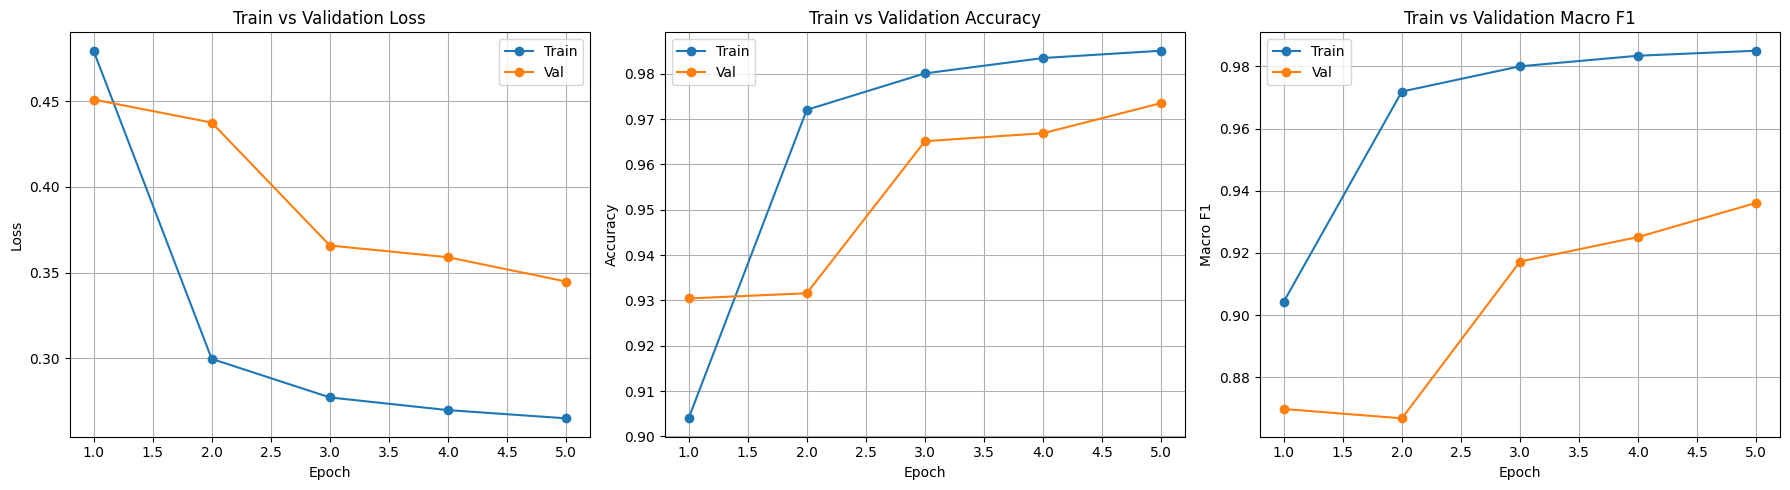


Best epoch: 5  Val Acc=0.9735  Val Macro F1=0.9361


In [11]:
#Training history visualization

history_df = pd.read_csv(HISTORY_PATH)
print("Training history:")
display(history_df)

metrics = [
    ("loss",     "Loss",     "Train vs Validation Loss"),
    ("accuracy", "Accuracy", "Train vs Validation Accuracy"),
    ("macro_f1", "Macro F1", "Train vs Validation Macro F1"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (key, ylabel, title) in zip(axes, metrics):
    ax.plot(history_df["epoch"], history_df[f"train_{key}"], marker="o", label="Train")
    ax.plot(history_df["epoch"], history_df[f"val_{key}"],   marker="o", label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

best_row = history_df.loc[history_df["val_macro_f1"].idxmax()]
print(f"\nBest epoch: {int(best_row['epoch'])}  "
      f"Val Acc={best_row['val_accuracy']:.4f}  "
      f"Val Macro F1={best_row['val_macro_f1']:.4f}")

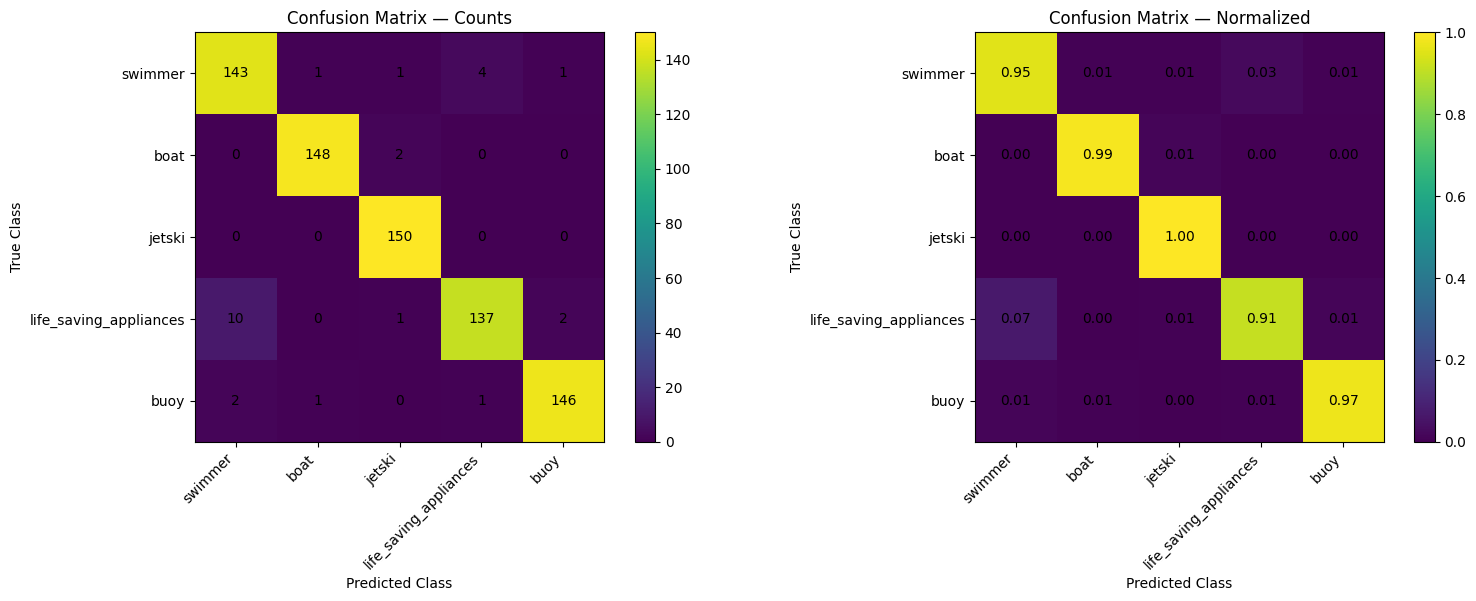

Most common mistakes:


,true,predicted,count,rate
5,life_saving_appliances,swimmer,10,0.066667
2,swimmer,life_saving_appliances,4,0.026667
4,boat,jetski,2,0.013333
8,buoy,swimmer,2,0.013333
7,life_saving_appliances,buoy,2,0.013333
1,swimmer,jetski,1,0.006667
0,swimmer,boat,1,0.006667
6,life_saving_appliances,jetski,1,0.006667
3,swimmer,buoy,1,0.006667
9,buoy,boat,1,0.006667


In [12]:
#Confusion matrix visualization

# Requires all_labels / all_preds from Cell 9
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]
cm           = confusion_matrix(all_labels, all_preds)
cm_norm      = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix — Counts", "Confusion Matrix — Normalized"],
    ["{:.0f}", "{:.2f}"],
):
    im = ax.imshow(data, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(target_names, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(target_names)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Most common misclassifications
mistakes = [
    {"true": target_names[r], "predicted": target_names[c],
     "count": int(cm[r, c]), "rate": cm_norm[r, c]}
    for r in range(NUM_CLASSES) for c in range(NUM_CLASSES) if r != c and cm[r, c] > 0
]
if mistakes:
    mistakes_df = pd.DataFrame(mistakes).sort_values("count", ascending=False)
    print("Most common mistakes:")
    display(mistakes_df)
else:
    print("No classification mistakes found.")

In [13]:
#
Model summary

from collections import Counter as _Counter

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MobileViT-S — SeaDronesSee Classifier Summary")
print("=" * 60)
print(f"Architecture : MobileViT-S (timm)")
print(f"Input        : {IMG_SIZE}×{IMG_SIZE} RGB patches")
print(f"Output       : {NUM_CLASSES} classes")
print(f"Total params : {total:,}")
print(f"Trainable    : {trainable:,}  ({100*trainable/total:.2f}%)")
print(f"Frozen       : {total-trainable:,}")
print("\nClasses:")
for i, name in idx_to_class.items():
    print(f"  {i} → {name}")

if BEST_MODEL_PATH.exists():
    ckpt = torch.load(BEST_MODEL_PATH, map_location="cpu")
    print(f"\nBest checkpoint  epoch={ckpt['epoch']}  "
          f"val_macro_f1={ckpt['val_macro_f1']:.4f}")

if HISTORY_PATH.exists():
    df       = pd.read_csv(HISTORY_PATH)
    best_row = df.loc[df["val_macro_f1"].idxmax()]
    print("\nFull training history:")
    display(df)
    print(f"\nBest row  →  epoch={int(best_row['epoch'])}  "
          f"val_acc={best_row['val_accuracy']:.4f}  "
          f"val_f1={best_row['val_macro_f1']:.4f}")

MobileViT-S — SeaDronesSee Classifier Summary
Architecture : MobileViT-S (timm)
Input        : 224×224 RGB patches
Output       : 5 classes
Total params : 4,940,837
Trainable    : 2,421,077  (49.00%)
Frozen       : 2,519,760

Classes:
  0 → swimmer
  1 → boat
  2 → jetski
  3 → life_saving_appliances
  4 → buoy

Best checkpoint  epoch=5  val_macro_f1=0.9361

Full training history:


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,1,0.479327,0.903981,0.904289,0.450876,0.930426,0.869824
1,2,0.299771,0.972035,0.971935,0.437459,0.931568,0.866809
2,3,0.277303,0.980070,0.980061,0.365814,0.965109,0.917249
3,4,0.269905,0.983456,0.983463,0.358992,0.966874,0.925144
4,5,0.265119,0.985070,0.985072,0.344817,0.973520,0.936136



Best row  →  epoch=5  val_acc=0.9735  val_f1=0.9361
